# Natural Language Processing

In [ ]:
Name: "Rishitha Adapa"
Student ID: "801461577"

## Importing the libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the dataset

In [36]:
train_df = pd.read_csv(r"C:\Users\adapa\Downloads\Project_Dataset\yelp_review_polarity_csv\train.csv",
                       header=None, names=["label","text"])

test_df = pd.read_csv(r"C:\Users\adapa\Downloads\Project_Dataset\yelp_review_polarity_csv\test.csv",
                      header=None, names=["label","text"])

Checking whether the dataset is imported correctly or not

In [37]:
print(train_df.head(10))
print(test_df.head(10))

   label                                               text
0      1  Unfortunately, the frustration of being Dr. Go...
1      2  Been going to Dr. Goldberg for over 10 years. ...
2      1  I don't know what Dr. Goldberg was like before...
3      1  I'm writing this review to give you a heads up...
4      2  All the food is great here. But the best thing...
5      1  Wing sauce is like water. Pretty much a lot of...
6      1  Owning a driving range inside the city limits ...
7      1  This place is absolute garbage...  Half of the...
8      2  Before I finally made it over to this range I ...
9      2  I drove by yesterday to get a sneak peak.  It ...
   label                                               text
0      2  Contrary to other reviews, I have zero complai...
1      1  Last summer I had an appointment to get new ti...
2      2  Friendly staff, same starbucks fair you get an...
3      1  The food is good. Unfortunately the service is...
4      2  Even when we didn't have a car

In [22]:
print(train_df.shape)
print(test_df.shape)

(560000, 2)
(38000, 2)


Separating Independent Variable into x and Target Variable into y

In [23]:
# training data
x_train = train_df.iloc[:, 1]   
y_train = train_df.iloc[:, 0]   

# test data
x_test = test_df.iloc[:, 1]
y_test = test_df.iloc[:, 0]

In [24]:
print(x_train)

0         Unfortunately, the frustration of being Dr. Go...
1         Been going to Dr. Goldberg for over 10 years. ...
2         I don't know what Dr. Goldberg was like before...
3         I'm writing this review to give you a heads up...
4         All the food is great here. But the best thing...
                                ...                        
559995    Ryan was as good as everyone on yelp has claim...
559996    Professional \nFriendly\nOn time AND affordabl...
559997    Phone calls always go to voicemail and message...
559998    Looks like all of the good reviews have gone t...
559999    Ryan Rocks! I called him this morning for some...
Name: text, Length: 560000, dtype: object


In [25]:
print(y_train)

0         1
1         2
2         1
3         1
4         2
         ..
559995    2
559996    2
559997    1
559998    1
559999    2
Name: label, Length: 560000, dtype: int64


In [26]:
print(x_test)

0        Contrary to other reviews, I have zero complai...
1        Last summer I had an appointment to get new ti...
2        Friendly staff, same starbucks fair you get an...
3        The food is good. Unfortunately the service is...
4        Even when we didn't have a car Filene's Baseme...
                               ...                        
37995           If I could give 0...I would.  Don't do it.
37996    Items Selected:\nChocolate Cinnamon Horn\nSmal...
37997    Expensive lunch meals.  Fried pickles were goo...
37998    Highly overpriced and food was cold. Our waitr...
37999    I have been using this company for 11 months. ...
Name: text, Length: 38000, dtype: object


In [27]:
print(y_test)

0        2
1        1
2        2
3        1
4        2
        ..
37995    1
37996    2
37997    1
37998    1
37999    1
Name: label, Length: 38000, dtype: int64


## Cleaning the texts

In [38]:
# Selecting a subset of the training data for faster preprocessing
x_train = x_train[:100000]
y_train = y_train[:100000]

In [39]:
# Importing required libraries
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# Loading English stopwords
stop_words = set(stopwords.words('english'))

# Keep "not" because it is important for sentiment analysis
stop_words.discard('not')


# Function to clean and remove stopwords
def clean_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove numbers and special characters
    text = re.sub('[^a-zA-Z]', ' ', text)
    
    # Split the text into words
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Join the cleaned words back into a sentence
    text = ' '.join(words)
    
    return text


# Apply cleaning to the training data
x_train = x_train.apply(clean_text)

# Apply the same cleaning to the test data
x_test = x_test.apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adapa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [30]:
x_train.head()

0    unfortunately frustration dr goldberg patient ...
1    going dr goldberg years think one st patients ...
2    know dr goldberg like moving arizona let tell ...
3    writing review give heads see doctor office st...
4    food great best thing wings wings simply fanta...
Name: text, dtype: object

In [31]:
x_test.head()

0    contrary reviews zero complaints service price...
1    last summer appointment get new tires wait sup...
2    friendly staff starbucks fair get anywhere els...
3    food good unfortunately service hit miss main ...
4    even car filene basement worth bus trip waterf...
Name: text, dtype: object

## Creating the Bag of Words model

In [40]:
# CountVectorizer converts text into a matrix of token counts
from sklearn.feature_extraction.text import CountVectorizer

# max_features limits the vocabulary size to the most frequent 5000 words
# This helps reduce memory usage and improves model efficiency
cv = CountVectorizer(max_features=5000)

# Fit the model on the training data and transform it into a Bag-of-Words matrix
# Each row represents a review and each column represents a word in the vocabulary
X_train_bow = cv.fit_transform(x_train).toarray()

# Transform the test data using the same vocabulary learned from the training data
# This ensures consistency between training and testing datasets
X_test_bow = cv.transform(x_test).toarray()

## Training the Naive Bayes model on the Training set

In [42]:
# Training the Naive Bayes model

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Naive Bayes classifier
nb_model = MultinomialNB()

# Train the model using the training data
nb_model.fit(X_train_bow, y_train)

# Predict the sentiment for the test data
y_pred_nb = nb_model.predict(X_test_bow)

# Calculate accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

# Display detailed evaluation metrics
print(classification_report(y_test, y_pred_nb))

# Example predictions
print("Sample Predictions (Naive Bayes):")
for i in range(5):
    print("Review:", x_test.iloc[i])
    print("Predicted Sentiment:", y_pred_nb[i])
    print("Actual Sentiment:", y_test.iloc[i])
    print()

Naive Bayes Accuracy: 0.8576052631578948
              precision    recall  f1-score   support

           1       0.89      0.81      0.85     19000
           2       0.83      0.90      0.86     19000

    accuracy                           0.86     38000
   macro avg       0.86      0.86      0.86     38000
weighted avg       0.86      0.86      0.86     38000

Sample Predictions (Naive Bayes):
Review: contrary reviews zero complaints service prices getting tire service past years compared experience places like pep boys guys experienced know nalso one place not feel like taken advantage gender auto mechanics notorious capitalizing ignorance cars sucked bank account dry service road coverage well explained let decide nand renovated waiting room looks lot better previous years
Predicted Sentiment: 1
Actual Sentiment: 2

Review: last summer appointment get new tires wait super long time also went week fix minor problem tire put fixed free next morning issue called complain manager ev

In [34]:
## Training the Logistic Regression Model on the Training Set

SyntaxError: invalid syntax (2576069459.py, line 1)

In [43]:
# Training the Logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression classifier
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train_bow, y_train)

# Predict sentiments for the test data
y_pred_lr = lr_model.predict(X_test_bow)

# Evaluate model performance
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Example predictions
print("Sample Predictions (Logistic Regression):")
for i in range(5):
    print("Review:", x_test.iloc[i])
    print("Predicted Sentiment:", y_pred_lr[i])
    print("Actual Sentiment:", y_test.iloc[i])
    print()

Logistic Regression Accuracy: 0.9172894736842105
              precision    recall  f1-score   support

           1       0.92      0.92      0.92     19000
           2       0.92      0.92      0.92     19000

    accuracy                           0.92     38000
   macro avg       0.92      0.92      0.92     38000
weighted avg       0.92      0.92      0.92     38000

Sample Predictions (Logistic Regression):
Review: contrary reviews zero complaints service prices getting tire service past years compared experience places like pep boys guys experienced know nalso one place not feel like taken advantage gender auto mechanics notorious capitalizing ignorance cars sucked bank account dry service road coverage well explained let decide nand renovated waiting room looks lot better previous years
Predicted Sentiment: 1
Actual Sentiment: 2

Review: last summer appointment get new tires wait super long time also went week fix minor problem tire put fixed free next morning issue called com

In [ ]:
## Training the Support Vector Machine Model on the Training Set

In [44]:
# Training the Support Vector Machine model

from sklearn.svm import LinearSVC

# Initialize the SVM classifier
svm_model = LinearSVC()

# Train the model
svm_model.fit(X_train_bow, y_train)

# Predict sentiments for the test data
y_pred_svm = svm_model.predict(X_test_bow)

# Evaluate model performance
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# Example predictions
print("Sample Predictions (SVM):")
for i in range(5):
    print("Review:", x_test.iloc[i])
    print("Predicted Sentiment:", y_pred_svm[i])
    print("Actual Sentiment:", y_test.iloc[i])
    print()

SVM Accuracy: 0.913921052631579
              precision    recall  f1-score   support

           1       0.91      0.92      0.91     19000
           2       0.91      0.91      0.91     19000

    accuracy                           0.91     38000
   macro avg       0.91      0.91      0.91     38000
weighted avg       0.91      0.91      0.91     38000

Sample Predictions (SVM):
Review: contrary reviews zero complaints service prices getting tire service past years compared experience places like pep boys guys experienced know nalso one place not feel like taken advantage gender auto mechanics notorious capitalizing ignorance cars sucked bank account dry service road coverage well explained let decide nand renovated waiting room looks lot better previous years
Predicted Sentiment: 1
Actual Sentiment: 2

Review: last summer appointment get new tires wait super long time also went week fix minor problem tire put fixed free next morning issue called complain manager even apologize frus

## Evaluating model performance using accuracy score and classification report

In [45]:
# Evaluating Model Performance

from sklearn.metrics import accuracy_score, classification_report

# Accuracy for each model
nb_acc = accuracy_score(y_test, y_pred_nb)
lr_acc = accuracy_score(y_test, y_pred_lr)
svm_acc = accuracy_score(y_test, y_pred_svm)

print("Naive Bayes Accuracy:", nb_acc)
print("Logistic Regression Accuracy:", lr_acc)
print("SVM Accuracy:", svm_acc)

# Detailed classification metrics
print("\nNaive Bayes Report:\n", classification_report(y_test, y_pred_nb))
print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("\nSVM Report:\n", classification_report(y_test, y_pred_svm))

Naive Bayes Accuracy: 0.8576052631578948
Logistic Regression Accuracy: 0.9172894736842105
SVM Accuracy: 0.913921052631579

Naive Bayes Report:
               precision    recall  f1-score   support

           1       0.89      0.81      0.85     19000
           2       0.83      0.90      0.86     19000

    accuracy                           0.86     38000
   macro avg       0.86      0.86      0.86     38000
weighted avg       0.86      0.86      0.86     38000


Logistic Regression Report:
               precision    recall  f1-score   support

           1       0.92      0.92      0.92     19000
           2       0.92      0.92      0.92     19000

    accuracy                           0.92     38000
   macro avg       0.92      0.92      0.92     38000
weighted avg       0.92      0.92      0.92     38000


SVM Report:
               precision    recall  f1-score   support

           1       0.91      0.92      0.91     19000
           2       0.91      0.91      0.91     1

## Creating Confusion Matrix

In [46]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Naive Bayes Confusion Matrix:\n", cm_nb)
print("\nLogistic Regression Confusion Matrix:\n", cm_lr)
print("\nSVM Confusion Matrix:\n", cm_svm)

Naive Bayes Confusion Matrix:
 [[15483  3517]
 [ 1894 17106]]

Logistic Regression Confusion Matrix:
 [[17465  1535]
 [ 1608 17392]]

SVM Confusion Matrix:
 [[17385  1615]
 [ 1656 17344]]


In [ ]:
## confusion matrix visualization using best model of all three

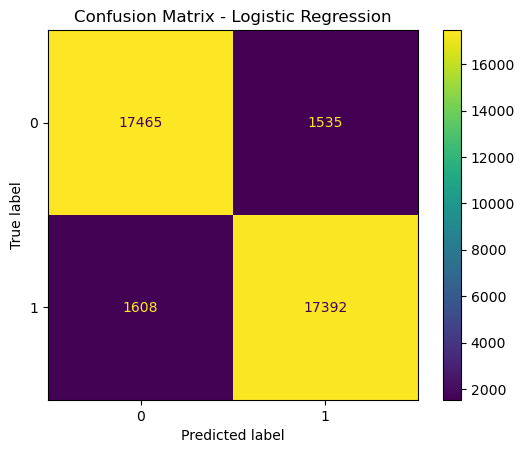

In [47]:
# Import required libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

# Add title for better presentation
plt.title("Confusion Matrix - Logistic Regression")

# Show the plot
plt.show()

In [ ]:
## precision, recall, f1-score evaluation

In [48]:
# Precision, Recall, F1-score

from sklearn.metrics import precision_score, recall_score, f1_score

print("Naive Bayes Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Naive Bayes Recall:", recall_score(y_test, y_pred_nb, average='weighted'))
print("Naive Bayes F1 Score:", f1_score(y_test, y_pred_nb, average='weighted'))

print("\nLogistic Regression Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_lr, average='weighted'))
print("Logistic Regression F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))

print("\nSVM Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("SVM Recall:", recall_score(y_test, y_pred_svm, average='weighted'))
print("SVM F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))

Naive Bayes Precision: 0.8602338013934369
Naive Bayes Recall: 0.8576052631578948
Naive Bayes F1 Score: 0.8573450335289645

Logistic Regression Precision: 0.917295633707568
Logistic Regression Recall: 0.9172894736842105
Logistic Regression F1 Score: 0.9172891684445835

SVM Precision: 0.9139229800679488
SVM Recall: 0.913921052631579
SVM F1 Score: 0.913920952424599


In [ ]:
## Table for Model Comparison

In [49]:
# Model Comparison Table

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Accuracy": [nb_acc, lr_acc, svm_acc],
    "Precision": [
        precision_score(y_test, y_pred_nb, average='weighted'),
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ]
})

print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.857605   0.860234  0.857605  0.857345
1  Logistic Regression  0.917289   0.917296  0.917289  0.917289
2                  SVM  0.913921   0.913923  0.913921  0.913921


In [ ]:
## Accuracy Visualization

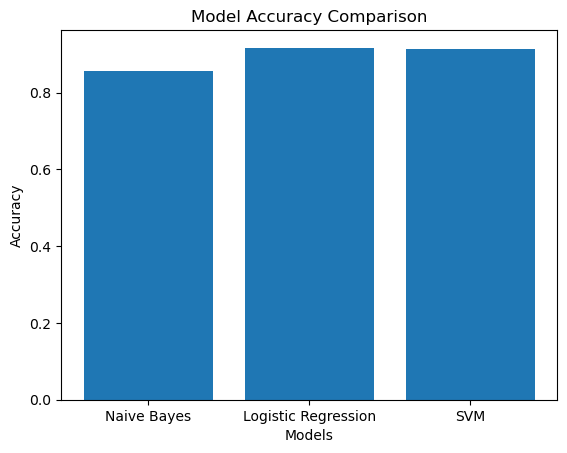

In [50]:
# Visualizing Accuracy Comparison

import matplotlib.pyplot as plt

plt.figure()
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
## Sample prediction by all the three models

In [51]:
# Sample Predictions

for i in range(5):
    print("Review:", x_test.iloc[i])
    print("Actual:", y_test.iloc[i])
    print("Naive Bayes:", y_pred_nb[i])
    print("Logistic Regression:", y_pred_lr[i])
    print("SVM:", y_pred_svm[i])
    print()

Review: contrary reviews zero complaints service prices getting tire service past years compared experience places like pep boys guys experienced know nalso one place not feel like taken advantage gender auto mechanics notorious capitalizing ignorance cars sucked bank account dry service road coverage well explained let decide nand renovated waiting room looks lot better previous years
Actual: 2
Naive Bayes: 1
Logistic Regression: 1
SVM: 1

Review: last summer appointment get new tires wait super long time also went week fix minor problem tire put fixed free next morning issue called complain manager even apologize frustrated never going back seem overpriced
Actual: 1
Naive Bayes: 1
Logistic Regression: 2
SVM: 2

Review: friendly staff starbucks fair get anywhere else sometimes lines get long
Actual: 2
Naive Bayes: 2
Logistic Regression: 2
SVM: 2

Review: food good unfortunately service hit miss main issue seems kitchen waiters waitresses often apologetic long waits pretty obvious avoi

In [ ]:
## Below code is for showing the error analysis

In [52]:
# Error Analysis (SVM)

errors = []

for i in range(len(y_test)):
    if y_test.iloc[i] != y_pred_svm[i]:
        errors.append((x_test.iloc[i], y_test.iloc[i], y_pred_svm[i]))

# Show first 5 incorrect predictions
for i in range(5):
    print("Review:", errors[i][0])
    print("Actual:", errors[i][1])
    print("Predicted:", errors[i][2])
    print()

Review: contrary reviews zero complaints service prices getting tire service past years compared experience places like pep boys guys experienced know nalso one place not feel like taken advantage gender auto mechanics notorious capitalizing ignorance cars sucked bank account dry service road coverage well explained let decide nand renovated waiting room looks lot better previous years
Actual: 2
Predicted: 1

Review: last summer appointment get new tires wait super long time also went week fix minor problem tire put fixed free next morning issue called complain manager even apologize frustrated never going back seem overpriced
Actual: 1
Predicted: 2

Review: go distributer great selection lots hard find brews noticed expensive going elsewhere honestly buy buying six packs know huuugggge rip time case something love feel like getting bargain cold selection suck try plan ahead need already cold staff helpful recommendations ask
Actual: 2
Predicted: 1

Review: quite times always try like 